**Previously on:** Lecture 34 asked whether you could say, in one sentence, where a dataset
came from. Today gives you the most uncomfortable version of that question: what happens when
the numbers you need were never released as numbers at all, only as pixels in someone else's
plot -- and *you* are the one about to generate the "data"?

Today's topics:
* digitizing a plot image into numbers, conceptually (WebPlotDigitizer, by name)
* `np.interp` -- linear interpolation between known points
* `scipy.interpolate.CubicSpline` -- a smoother interpolator, and when it disagrees with linear
* resampling two unevenly-sampled curves onto one shared grid so they can be compared

> By the end of today you should be able to complete Problems 1-3 of Homework 11: digitize a
> provided figure, interpolate to a target value, and resample two curves for honest comparison.

# The paper only has a picture

You need the stress at some strain from an old compression test. The number exists -- a machine
recorded it -- but it only ever left the lab as a plotted curve in a report. This happens
constantly with older or industry materials data. Today's dataset is exactly that situation, with
one convenience: the ground-truth digitized points already exist, so we can spend today on the
*interpolation* half of the problem and let Homework 11 be where you do the clicking yourself.

## Dataset: Digitizing Exercise — Lattice Compression Stress-Strain Chart

This is NOT a normal regression dataset. It pairs a published stress-strain chart
(`digitizing_chart.png`, a compression test of a 3D-printed lattice structure showing
elastic deformation, a shear-band peak, densification, and post-peak oscillation) with
the ground-truth data points behind it (`digitizing_chart_data.csv`, 93 rows of `strain`,
`stress_MPa`). The intended exercise: show students the image first, have them digitize
a handful of points off the curve by eye (or with a tool), then compare their estimates
against this ground-truth CSV to see how digitizing/interpolation error behaves. Source:
Wes's own course archive (`lecture27-chart.PNG` / `lecture27-data.csv`).

93 ground-truth (strain, stress) points; chart image at ../../../datasets/digitizing_chart.png


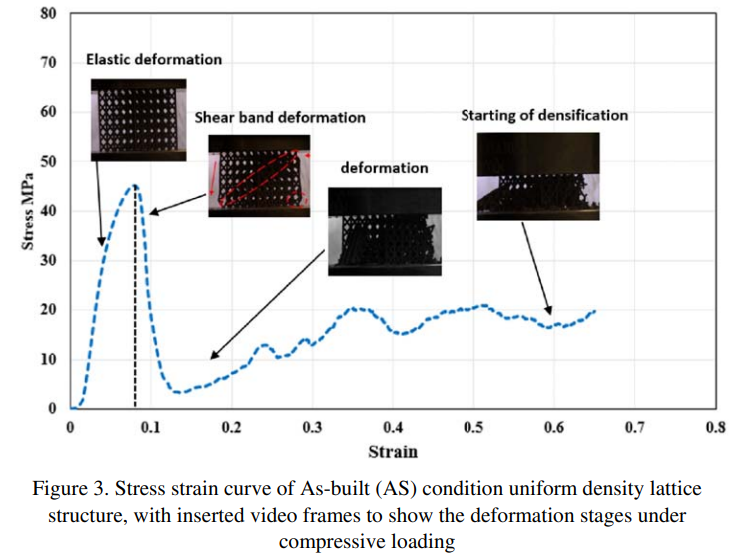

,strain,stress_MPa
0,0.005130,-0.027811
1,0.013798,1.232619
2,0.017513,3.530355
3,0.019990,6.064491
4,0.021848,8.378969


In [1]:
import os
import pandas as pd
from IPython.display import Image, display

_image_file = 'digitizing_chart.png'
_data_file = 'digitizing_chart_data.csv'
_github_image = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_image_file}'
_github_data = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_data_file}'

_local_image = next(
    (p for p in (f'datasets/{_image_file}', f'../datasets/{_image_file}', f'../../datasets/{_image_file}', f'../../../datasets/{_image_file}')
     if os.path.exists(p)),
    None,
)
_local_data = next(
    (p for p in (f'datasets/{_data_file}', f'../datasets/{_data_file}', f'../../datasets/{_data_file}', f'../../../datasets/{_data_file}')
     if os.path.exists(p)),
    None,
)

chart_image = _local_image if _local_image else _github_image

try:
    data = pd.read_csv(_local_data if _local_data else _github_data)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_data_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github_data}"
    ) from e

print(f'{len(data)} ground-truth (strain, stress) points; chart image at {chart_image}')
display(Image(filename=_local_image) if _local_image else Image(url=_github_image))
data.head()

### Why this one?

Every real materials-science plot you'll ever see in a paper or datasheet started life
as raw numbers — but often you only have the picture, not the numbers. This lets
students practice the unglamorous but essential skill of turning a plotted curve back
into data: given the chart above, how would you estimate the stress at a strain of 0.3?
How much does your estimate depend on where exactly you click/read the curve? We can
check any student's by-eye digitization against the real ground-truth points below.

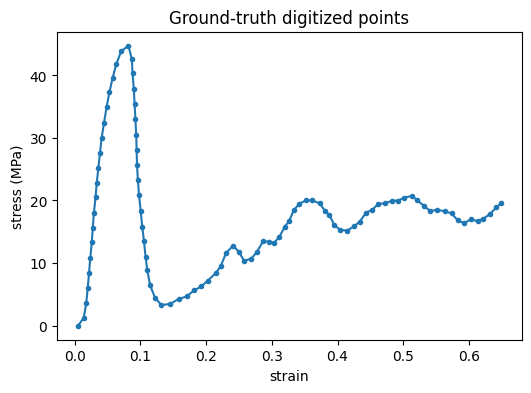

,strain,stress_MPa
count,93.000000,93.000000
mean,0.259228,18.320028
std,0.199639,10.090220
min,0.005130,-0.027811
25%,0.089958,11.795165
50%,0.222463,17.803953
75%,0.425555,20.445551
max,0.648461,44.745804


In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(data['strain'], data['stress_MPa'], 'o-', markersize=3)
ax.set_xlabel('strain')
ax.set_ylabel('stress (MPa)')
ax.set_title('Ground-truth digitized points')
plt.show()

data.describe()

A compression test of a 3D-printed lattice structure: a steep elastic rise, a sharp peak where a
shear band forms, then post-peak softening with the oscillation of individual struts collapsing
layer by layer. Every one of those 93 points started life as a pixel someone (or something)
clicked on.

# WebPlotDigitizer, conceptually

The standard tool for this job is free and browser-based: [WebPlotDigitizer](https://apps.automeris.io/wpd4/).
The workflow, narrated rather than clicked through live -- you'll do the hands-on version on
Homework 11:
1. Load the image, then **calibrate the axes** by clicking two known x points and two known y
   points and typing in their true values. Notice what this step actually is: given two known
   (pixel, value) pairs, find the value at every other pixel -- a straight-line interpolation
   problem, before you've digitized a single data point. It pays off again in a few minutes.
2. Pick the trace color (or click points manually), and let the tool walk the curve.
3. Export as a CSV -- exactly the kind of file `dataset_digitizing_chart.py` just loaded for you.

Name the failure modes explicitly, because they're where digitizing error actually comes from:
a mis-clicked calibration point throws off the scale for *every* subsequent point; the color
picker can grab a gridline or legend swatch instead of the data; and oversampling a flat region
while undersampling a sharp peak silently distorts the curve's shape.

# The problem: the points you have aren't the point you need

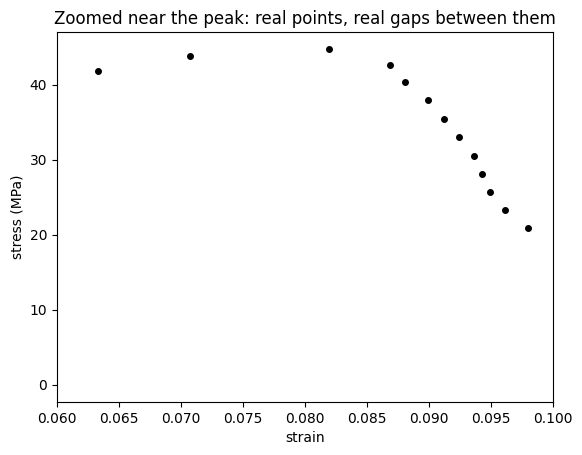

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(data['strain'], data['stress_MPa'], 'o', ms=4, color='k')
ax.set_xlim(0.06, 0.10)
ax.set_xlabel('strain'); ax.set_ylabel('stress (MPa)')
ax.set_title('Zoomed near the peak: real points, real gaps between them')
plt.show()

Zoomed on the peak, the points are visibly not evenly spaced -- an artifact of how the curve was
traced, not the material's true behavior. What's the stress at exactly 8.5% strain? Not one of
our 93 points. Name the answer: **interpolation**. (We won't hand-roll a nearest-neighbor loop
to get there -- you've already spent two modules on loops and indexing, and it's the weakest of
the honest strategies anyway.)

# `np.interp`: the fast, built-in answer

`np.interp(x_new, x_known, y_known)` is NumPy's built-in linear interpolator -- one call, no
object to build first:

In [4]:
import numpy as np

x, y = data['strain'].values, data['stress_MPa'].values
y_guess = np.interp(0.085, x, y)
print(f'stress at strain=0.085: {y_guess:.2f} MPa')

stress at strain=0.085: 43.42 MPa


It vectorizes over an array of query points at once -- directly useful later today for
resampling:

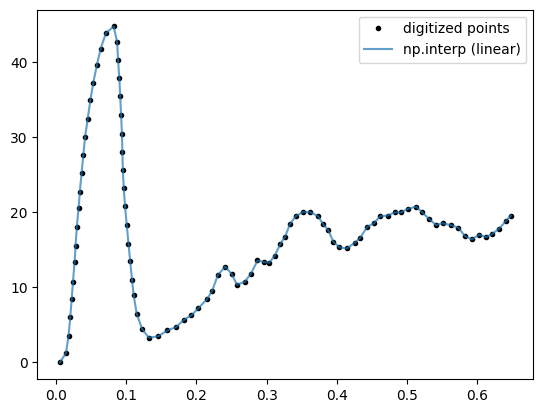

In [5]:
x_fine = np.linspace(x.min(), x.max(), 1000)
y_fine = np.interp(x_fine, x, y)

fig, ax = plt.subplots()
ax.plot(x, y, 'o', ms=3, color='k', label='digitized points')
ax.plot(x_fine, y_fine, '-', color='tab:blue', alpha=0.7, label='np.interp (linear)')
ax.legend()
plt.show()

It's doing exactly the point-slope line equation from algebra between each consecutive pair of
known points -- the same calibration move WebPlotDigitizer's axis-setup step performs:
$\hat y = y_i + (\hat x - x_i)\dfrac{y_{i+1}-y_i}{x_{i+1}-x_i}$

One caveat, stated plainly: `np.interp` silently **clamps** queries outside the known range to
the first/last y-value -- it will not warn you.

In [6]:
print(f'strain range in the data: {x.min():.3f} to {x.max():.3f}')
print(f'query far outside that range (strain=1.0): {np.interp(1.0, x, y):.2f} MPa (== last known y, flat and wrong)')

strain range in the data: 0.005 to 0.648
query far outside that range (strain=1.0): 19.53 MPa (== last known y, flat and wrong)


And before you conclude the smoother tool we meet next is safer out of range: it is *worse*.
A cubic spline happily extrapolates its last polynomial segment, producing smooth-looking,
physically absurd numbers -- we'll print one below, after we've built it. Neither tool knows
any materials science; outside the data, *you* are the model.

# `scipy.interpolate.CubicSpline`: a smoother curve through the same points

`np.interp` is always straight-line. For a smoother curve through the same points, reach for
`scipy.interpolate.CubicSpline` -- the modern, recommended tool for this job (`interp1d`, which
older tutorials use, is now documented by SciPy itself as legacy in favor of `CubicSpline` and
related classes). This is Lecture 15's "consuming an object" pattern again, like the
`.predict()`-wrapped model from Lecture 20: build the object once, then call it for any new `x`.

In [7]:
from scipy.interpolate import CubicSpline

cubic_fn = CubicSpline(x, y)
print(f'linear:  {np.interp(0.085, x, y):.2f} MPa')
print(f'cubic:   {cubic_fn(0.085):.2f} MPa')

linear:  43.42 MPa
cubic:   44.62 MPa


The promised out-of-range check. `np.interp` clamped to a flat 19.53 MPa; the spline does
something far more dangerous -- it keeps drawing its last cubic segment:

In [8]:
print(f'cubic spline at strain=1.0: {cubic_fn(1.0):.0f} MPa  (a smooth-looking, physically absurd number)')

cubic spline at strain=1.0: -7500 MPa  (a smooth-looking, physically absurd number)


Zoom on the peak, where curvature is sharpest and points are relatively sparse -- this is where
the two methods actually disagree:

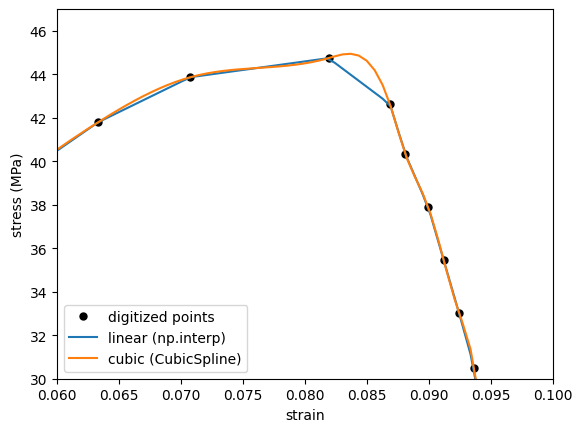

In [9]:
fig, ax = plt.subplots()
ax.plot(x, y, 'o', ms=5, color='k', label='digitized points')
ax.plot(x_fine, y_fine, '-', label='linear (np.interp)')
ax.plot(x_fine, cubic_fn(x_fine), '-', label='cubic (CubicSpline)')
ax.set_xlim(0.06, 0.10); ax.set_ylim(30, 47)
ax.set_xlabel('strain'); ax.set_ylabel('stress (MPa)')
ax.legend()
plt.show()

Visibly different curves through the *same* 93 points: linear cuts a straight edge across the
peak, while cubic overshoots slightly above it, using neighboring points' curvature instead of
just the two nearest. Neither is "more correct" -- they're different assumptions about what
happens between measurements, and the gap between them is real information about how much your
answer depends on that assumption.

# Resampling two curves onto a common grid

Motivating scenario: a labmate digitizes a second material's curve from a different figure, at
different, unevenly-spaced strain values. You can't directly subtract or compare two arrays that
live on different x-grids. Build a synthetic "Material B" so the resampling demo doesn't need a
second copyrighted figure:

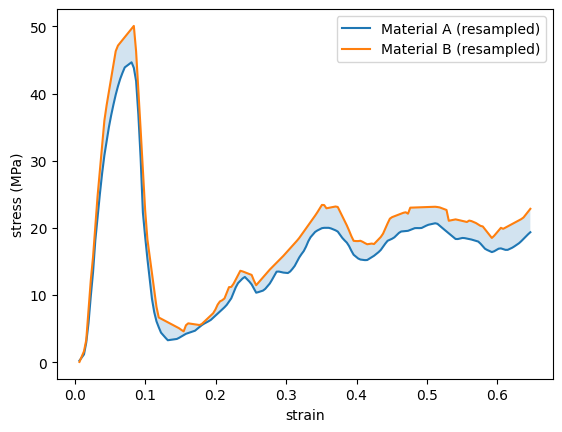

In [10]:
rng = np.random.default_rng(0)
x2 = np.sort(rng.uniform(x.min(), x.max(), 60))
y2 = np.interp(x2, x, y) * 1.15 + rng.normal(0, 0.5, size=x2.size)

common_x = np.linspace(max(x.min(), x2.min()), min(x.max(), x2.max()), 200)
y1_common = np.interp(common_x, x, y)
y2_common = np.interp(common_x, x2, y2)

fig, ax = plt.subplots()
ax.plot(common_x, y1_common, label='Material A (resampled)')
ax.plot(common_x, y2_common, label='Material B (resampled)')
ax.fill_between(common_x, y1_common, y2_common, alpha=0.2)
ax.set_xlabel('strain'); ax.set_ylabel('stress (MPa)')
ax.legend()
plt.show()

`common_x` is deliberately built from the *overlap* of both ranges -- `max` of the two minimums,
`min` of the two maximums. That's the interpolation/extrapolation boundary from two sections ago,
now load-bearing: resampling outside that overlap would silently extrapolate whichever curve runs
out first. This exact move -- overlap, then `np.interp` onto a shared grid -- is Homework 11
Problem 3.

# Honest error, and why you record the source

Quantify, don't just eyeball, how much linear and cubic disagree:

In [11]:
diff = np.abs(y_fine - cubic_fn(x_fine))
print(f'max linear/cubic disagreement anywhere: {diff.max():.2f} MPa, at strain={x_fine[np.argmax(diff)]:.3f}')
print(f'that is {diff.max() / y.max():.1%} of the curve\'s peak stress')

max linear/cubic disagreement anywhere: 1.20 MPa, at strain=0.085
that is 2.7% of the curve's peak stress


About 1.2 MPa, right at the peak -- small in absolute terms, but it's the single place on this
curve where "which interpolator did you use" changes your answer the most. Three honest
takeaways, matching Homework 11's "report a value *and* an uncertainty" expectation:
1. Digitizing itself has pixel-level error before any interpolation happens -- calibration
   clicks, line thickness, color-threshold noise -- typically a few percent, and it never shows
   up in an error bar unless you note it yourself.
2. Interpolation choice changes the answer, sometimes by a lot in sparse or high-curvature
   regions -- report which method you used.
3. Never extrapolate past the digitized range and call it data -- that's a model's guess, not a
   measurement, and must be labeled as such.

Close the loop to Lecture 34: every digitized dataset needs, at minimum, its source, the tool
used, and the interpolation method -- one line, every time:
`# Digitized from Wes's course archive (lecture27-chart.PNG / lecture27-data.csv) via
WebPlotDigitizer; CubicSpline used for resampling.` The moment you clicked the first point on
that chart, you became a link in this data's citation chain -- the exact habit Lecture 34 asked
you to build.

## [Check your understanding]

Estimate the stress at strain = 0.12 (just past the peak's steep drop, where the curve is
changing fast) using both `np.interp` and `cubic_fn`. Report both values and their difference in
MPa. Is this a region where you'd trust the two methods to agree, or not -- and how do you know,
from the shape of the curve alone, without rereading today's peak-region numbers? (Look at the
full-range plot from the resampling section -- strain 0.12 is off the right edge of the zoomed
peak plot.)

# Wrap-up

Three tools, one workflow: `np.interp` (fast, linear, clamps silently) -> `CubicSpline` (smoother,
a callable object, disagrees with linear most where curvature is sharp) -> resample both curves
onto an overlap `common_x` before comparing them.

**Take-home message:** an interpolated value is an estimate with two stacked sources of error --
how the point was digitized, and which interpolation method filled the gap -- and both belong in
the citation, not just the number.

For Homework 11: digitize a provided figure yourself, interpolate to answer a quantitative
question about it, and write the one-line provenance comment demonstrated above. Next class:
now that you can pull data *out* of someone else's rough old figure, we make sure yours never
needs that treatment.